# Avance 5 Final Model

### Integrantes:

- **A01794940** José de Jesús Peña Rodríguez.  
- **A01283104** Kevin Dueñas Aguirre.  
- **A01794191** Juan Antonio Chiñas Mata.

In [326]:
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import importlib
from sklearn.preprocessing import StandardScaler

In [327]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [328]:
warnings.filterwarnings("ignore")
CSV_PATH = "Datos_Imgenes.csv"

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/proj_int/Datos_Imgenes.csv")

In [329]:
def col_filter(input_df, col_to_filt, filt):
    filtered_df = input_df[input_df[col_to_filt] == filt]
    return filtered_df

In [330]:
def agg_graph(X_values, labels, graph_titles):
    num_rows = 1
    num_cols = 3


    num_plots = len(X_values)
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(20,5))
    axs = axs.flatten()

    for i, data in enumerate(X_values):
        axs[i].scatter(data[:,0], data[:,1], c=labels[i],cmap="viridis", marker="o")
        axs[i].set_title(graph_titles[i])

    plt.show()

## Data Preprocessing  
Based on a preliminary session with our tutor, we identified several columns that either lacked relevant information or contained redundant data already present in other columns. Consequently, we decided to remove the following columns:  

- `index`  
- `date`  
- `page`  
- `TotalPages`  
- `ModelApplied`  
- `Details`  
- `ModelReported`  

## Project Objective  
For this project, it was explicitly required to develop a solution and analysis to identify groups of documents acquired by different machine learning models.  

### Machine Learning Models  
The models involved in this process are:  

- `Model`  
- `Estado_cuenta`  
- `Recibo_nomina`  
- `INE`  
- `Comprobante_domicilio`  
- `Carta_libranza`

In [331]:
columns_to_delete = ["Index", "Date", "Page", "TotalPages","ModelApplied", "PagesProcessed", "ConfR", "ConfA", "ConfW","Details","ModelReported","DocType"]
df = df.drop(columns=columns_to_delete, axis=1)

# Creating a filter on Model column

## Data Filtering and Preparation  

In the following cells, we will apply filters to our base dataframe `df`, to extract a new dataframe called `models`.  

The `models` dataframe will allow us to apply further filtering and generate new dataframes, each containing the necessary information for clustering.  


In [332]:
models = df["Model"].value_counts()
models

,count
Model,
estado_cuenta,34140
recibo_nomina,10193
ine,9346
comprobante_domicilio,5780
carta_libranza,3501


## Filtered Dataframes  

By applying filters, we can generate new observations and create specific dataframes based on relevant criteria.  

- **`df_edo_cta`**: This dataframe will contain at least four distinct values in the `ClassId` column: `TXT`, `APP`, `SUC`, and `ATM`.  
- **`df_nom`**: This dataframe will have exactly four distinct values, using `DocType` as the reference column.  
- **`df_ine`**: This dataframe will contain only two distinct values, taking `DocType` as the reference column.  
- **`df_addy`**: This dataframe will include six different values, using `DocType` as the reference column.  
- **`df_lib`**: This dataframe will include six different values, using `DocType` as the reference column.  



## Displaying all diferent values in:
- `estado_cuenta`  
- `recibo_nomina`  
- `ine`  
- `comprobante_domicilio`  
- `carta libranza`

In [333]:
df_edo_cta = col_filter(df, "Model", "estado_cuenta")
df_nom = col_filter(df, "Model", "recibo_nomina")
df_ine = col_filter(df, "Model", "ine")
df_addy = col_filter(df, "Model", "comprobante_domicilio")
df_lib = col_filter(df, "Model", "carta_libranza")

# PREPROCESING PER MODEL

Since we are clustering based on the model type rather than the document type, we will start by dropping the Model and Classid columns, as all models have already been filtered and are ready for use.

In [334]:
df_edo_cta.drop(columns=["Model","ClassId"], inplace=True)
df_nom.drop(columns=["Model","ClassId"], inplace=True)
df_ine.drop(columns=["Model","ClassId"], inplace=True)
df_addy.drop(columns=["Model","ClassId"], inplace=True)
df_lib.drop(columns=["Model","ClassId"], inplace=True)

The feature set (X) will be the same for all clustering algorithms. Therefore, we first generate all possible feature pairs and combine them into a single list. This final X will serve as the input for each model we train.

In [335]:
df_edo_cta.columns

Index(['Fields', 'EmptyFields', 'Sharpness', 'Contrast', 'Clarity',
       'Resolution'],
      dtype='object')

# Definition of max number of clusters

In [336]:
agg_cluster = AgglomerativeClustering(n_clusters=3)


# Definition of the scaler

In [337]:
scaler = StandardScaler()

# Model: Estado de Cuenta

Select only Contrast, Clarity and resolution

In [338]:
#test
x_cols = [[3,4], [3,5], [4,5]]

In [339]:
X1 = df_edo_cta.iloc[:,x_cols[0]].values # Contrast and Clarity
X2 = df_edo_cta.iloc[:,x_cols[1]].values # Contrast and Resolution
X3 = df_edo_cta.iloc[:,x_cols[2]].values # Clarity and Resolution

Scaling the most valuable variable combinations

In [340]:
X1_edo_cta = scaler.fit_transform(X1)
X2_edo_cta = scaler.fit_transform(X2)
X3_edo_cta = scaler.fit_transform(X3)

In [341]:
y1_edo_cta= agg_cluster.fit_predict(X1_edo_cta)


In [342]:
y2_edo_cta = agg_cluster.fit_predict(X2_edo_cta)

In [343]:
y3_edo_cta = agg_cluster.fit_predict(X3_edo_cta)

In [344]:
graph_titles = ["Contrast & Clarity", "Contrast & Resolution", "Clarity & Resolution"]
labels_edo_cta = [y1_edo_cta, y2_edo_cta, y3_edo_cta]
X_edo_cta = [X1_edo_cta, X2_edo_cta, X3_edo_cta]

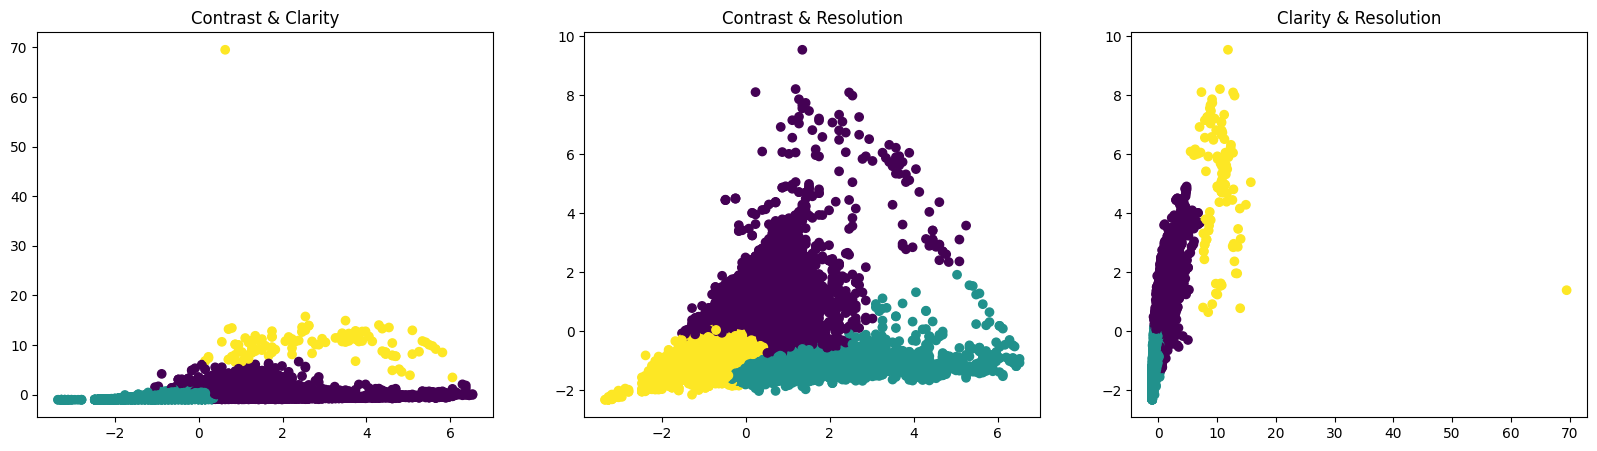

In [345]:
agg_graph(X_edo_cta, labels_edo_cta, graph_titles)

## Focus on Contrast and Resolution

In [346]:
temp_df = pd.DataFrame(X2_edo_cta, columns=['Contrast', 'Resolution'])
temp_df['Cluster'] = y2_edo_cta

for cluster_id in temp_df['Cluster'].unique():
    print(f"Cluster {cluster_id}:\n{temp_df[temp_df['Cluster'] == cluster_id]}\n")

Cluster 0:
       Contrast  Resolution  Cluster
0     -0.479966    0.036434        0
1     -0.559570    0.095599        0
2      1.748944    4.804121        0
4      0.714093   -0.648890        0
6     -0.479966    0.066016        0
...         ...         ...      ...
34134 -0.084641    0.205869        0
34136  0.063186    0.748667        0
34137  0.161464    0.856038        0
34138 -0.115868    0.537712        0
34139  0.148920    0.325501        0

[18522 rows x 3 columns]

Cluster 2:
       Contrast  Resolution  Cluster
3     -0.320758   -1.827254        2
7     -0.718777   -0.052313        2
9     -0.718777   -0.022731        2
10    -0.002342   -0.126269        2
11    -0.002342   -0.101617        2
...         ...         ...      ...
34123 -0.873924   -0.212063        2
34125 -0.893370   -0.196167        2
34130 -0.759586   -0.313224        2
34131 -0.791944   -0.356770        2
34132 -1.429964   -1.300924        2

[11402 rows x 3 columns]

Cluster 1:
       Contrast  Resoluti

## Number of EmptyFields

### Assumption: Our categorization is based on the number of EmptyFields detected. Therefore, a low number of EmptyFields indicates that the model is performing well, as it successfully extracts the necessary information with minimal omissions.

### In this step we are going to take a representative data for each cluster

In [347]:
print(df_edo_cta.iloc[6]["EmptyFields"]) #good perfomance
print(df_edo_cta.iloc[10]["EmptyFields"]) #regular perfomance
print(df_edo_cta.iloc[75]["EmptyFields"]) #bad perfomance

1.0

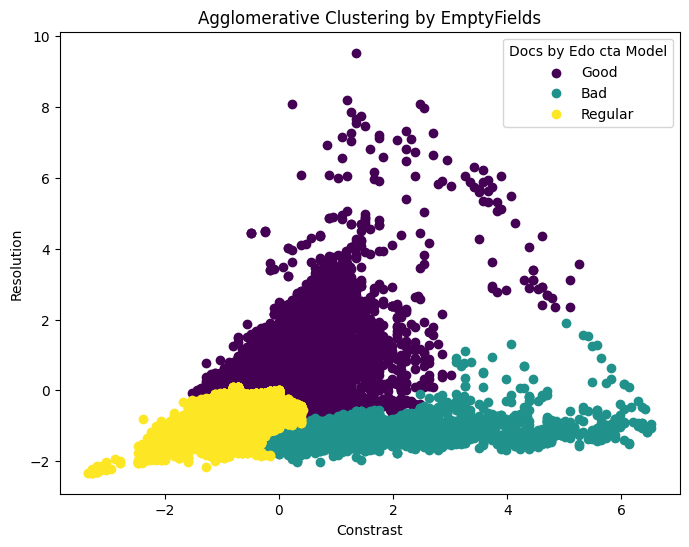

In [350]:
cluster_names = {0: 'Good', 1: 'Bad', 2: 'Regular'}
unique_clusters = np.unique(y2_edo_cta)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_clusters)))

plt.figure(figsize=(8, 6))

for cluster_id, color in zip(unique_clusters, colors):
    mask = y2_edo_cta == cluster_id
    plt.scatter(X2_edo_cta[mask, 0], X2_edo_cta[mask, 1],
                color=color, label=cluster_names[cluster_id], marker='o')

plt.title('Agglomerative Clustering by EmptyFields')
plt.xlabel('Constrast')
plt.ylabel('Resolution')

plt.legend(title="Docs by Edo cta Model")
plt.show()


# Model: Recibo de Nomina

In [351]:
X1 = df_nom.iloc[:,x_cols[0]].values # Contrast and Clarity
X2 = df_nom.iloc[:,x_cols[1]].values # Contrast and Resolution
X3 = df_nom.iloc[:,x_cols[2]].values # Clarity and Resolution

In [352]:
X1_nom = scaler.fit_transform(X1)
X2_nom = scaler.fit_transform(X2)
X3_nom = scaler.fit_transform(X3)

In [353]:
y1_nom = agg_cluster.fit_predict(X1_nom)

In [354]:
y2_nom = agg_cluster.fit_predict(X2_nom)

In [355]:
y3_nom = agg_cluster.fit_predict(X3_nom)

In [356]:
labels_nom = [y1_nom, y2_nom, y3_nom]
X_nom = [X1_nom, X2_nom, X3_nom]

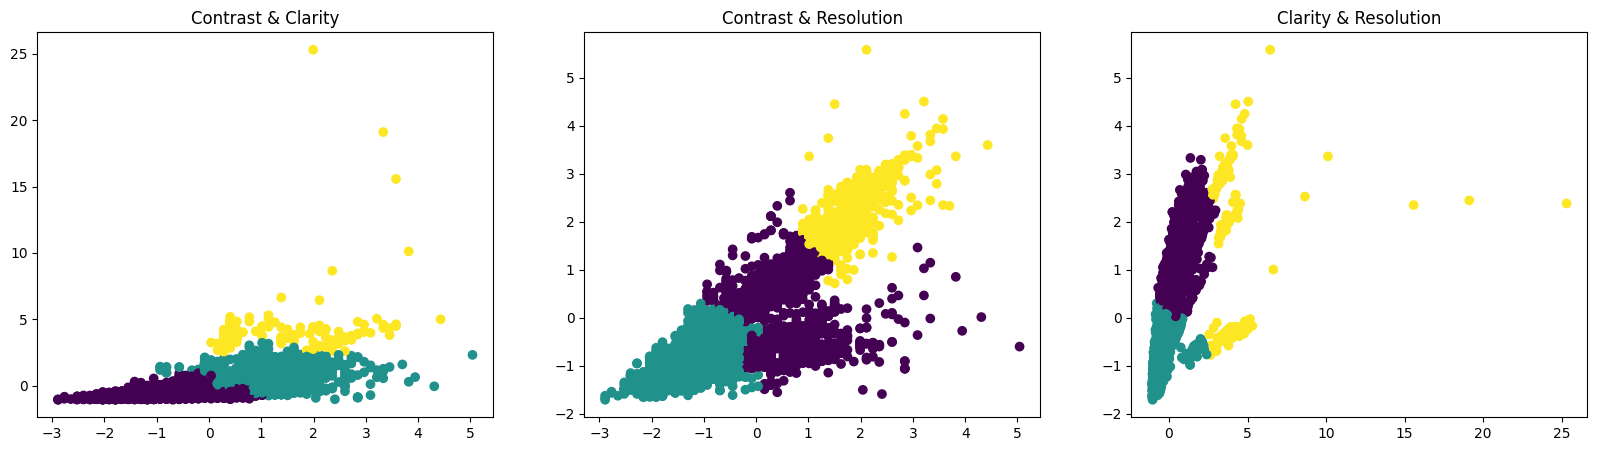

In [357]:
agg_graph(X_nom, labels_nom, graph_titles)

# Modelo INE

In [358]:
X1 = df_ine.iloc[:,x_cols[0]].values # Contrast and Clarity
X2 = df_ine.iloc[:,x_cols[1]].values # Contrast and Resolution
X3 = df_ine.iloc[:,x_cols[2]].values # Clarity and Resolution

In [359]:
X1_ine = scaler.fit_transform(X1)
X2_ine = scaler.fit_transform(X2)
X3_ine = scaler.fit_transform(X3)

In [360]:
y1_ine = agg_cluster.fit_predict(X1_ine)

In [361]:
y2_ine = agg_cluster.fit_predict(X2_ine)

In [362]:
y3_ine = agg_cluster.fit_predict(X3_ine)

In [363]:
labels_ine = [y1_ine, y2_ine, y3_ine]
X_ine = [X1_ine, X2_ine, X3_ine]

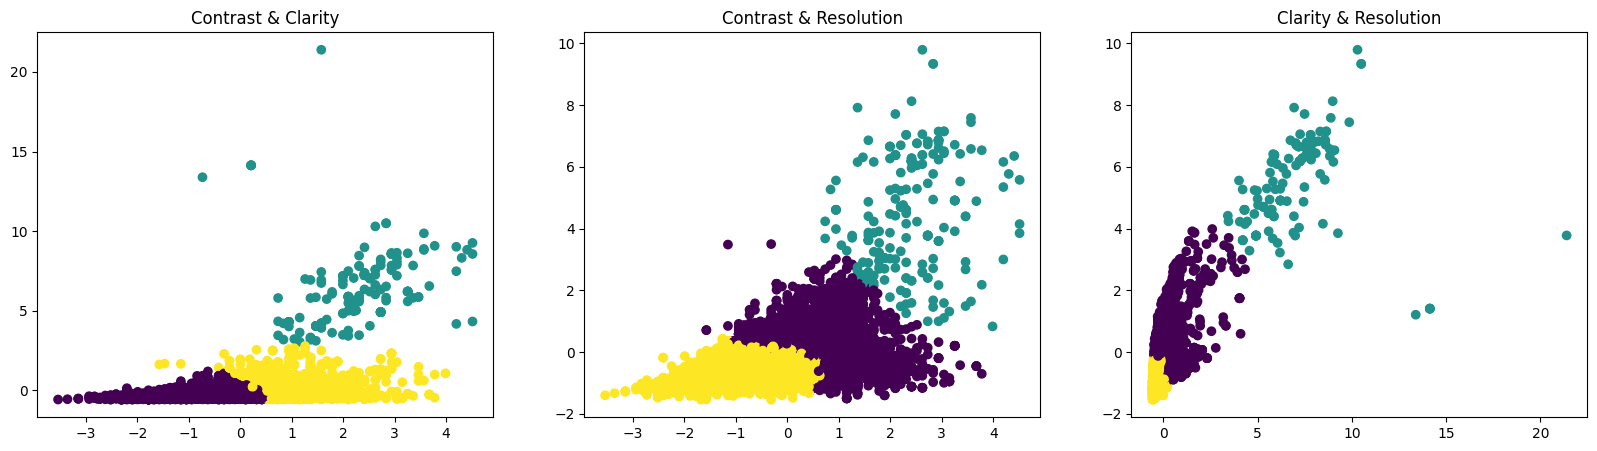

In [364]:
agg_graph(X_ine, labels_ine, graph_titles)

# Modelo Comprobante Domicilio

In [365]:
X1 = df_addy.iloc[:,x_cols[0]].values # Contrast and Clarity
X2 = df_addy.iloc[:,x_cols[1]].values # Contrast and Resolution
X3 = df_addy.iloc[:,x_cols[2]].values # Clarity and Resolution

In [366]:
X1_addy = scaler.fit_transform(X1)
X2_addy = scaler.fit_transform(X2)
X3_addy = scaler.fit_transform(X3)

In [367]:
y1_addy = agg_cluster.fit_predict(X1_addy)

In [368]:
y2_addy = agg_cluster.fit_predict(X2_addy)

In [369]:
y3_addy = agg_cluster.fit_predict(X3_addy)

In [370]:
labels_addy = [y1_addy, y2_addy, y3_addy]
X_addy = [X1_addy, X2_addy, X3_addy]

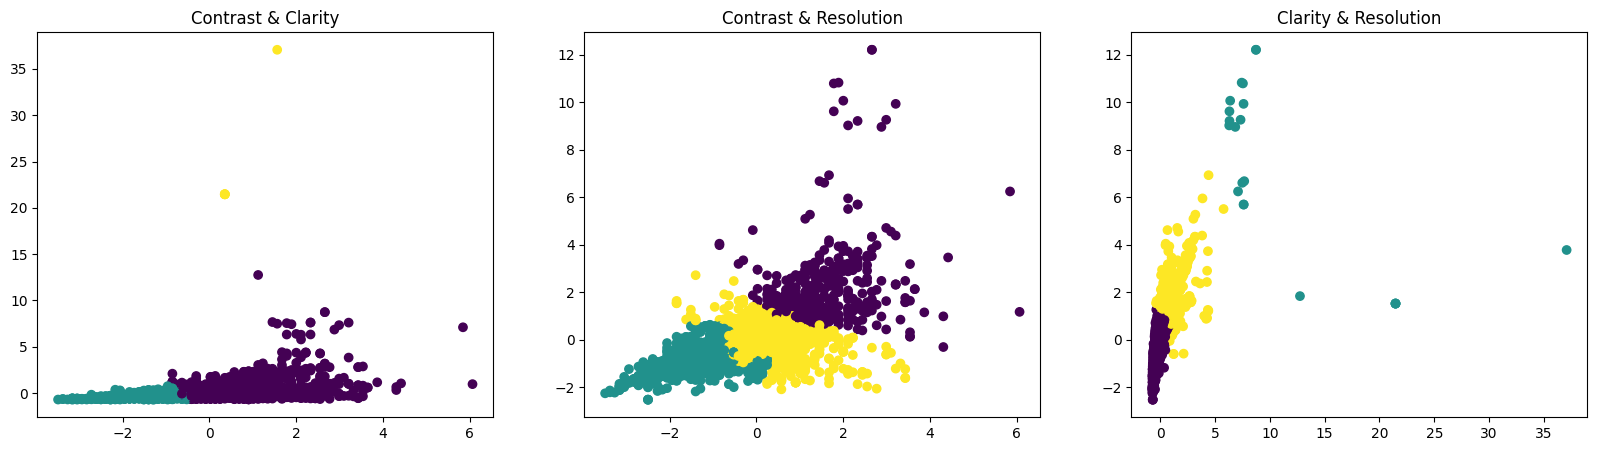

In [371]:
agg_graph(X_addy, labels_addy, graph_titles)

# Modelo Carta Libranza

## This models needs a small number of clusters.

In [372]:
agg_cluster = AgglomerativeClustering(n_clusters=2)

In [373]:
X1 = df_lib.iloc[:,x_cols[0]].values # Contrast and Clarity
X2 = df_lib.iloc[:,x_cols[1]].values # Contrast and Resolution
X3 = df_lib.iloc[:,x_cols[2]].values # Clarity and Resolution

In [374]:
X1_lib = scaler.fit_transform(X1)
X2_lib = scaler.fit_transform(X2)
X3_lib = scaler.fit_transform(X3)

In [375]:
y1_lib = agg_cluster.fit_predict(X1_lib)

In [376]:
y2_lib = agg_cluster.fit_predict(X2_lib)

In [377]:
y3_lib = agg_cluster.fit_predict(X3_lib)

In [378]:
labels_lib = [y1_lib, y2_lib, y3_lib]
X_lib = [X1_lib, X2_lib, X3_lib]

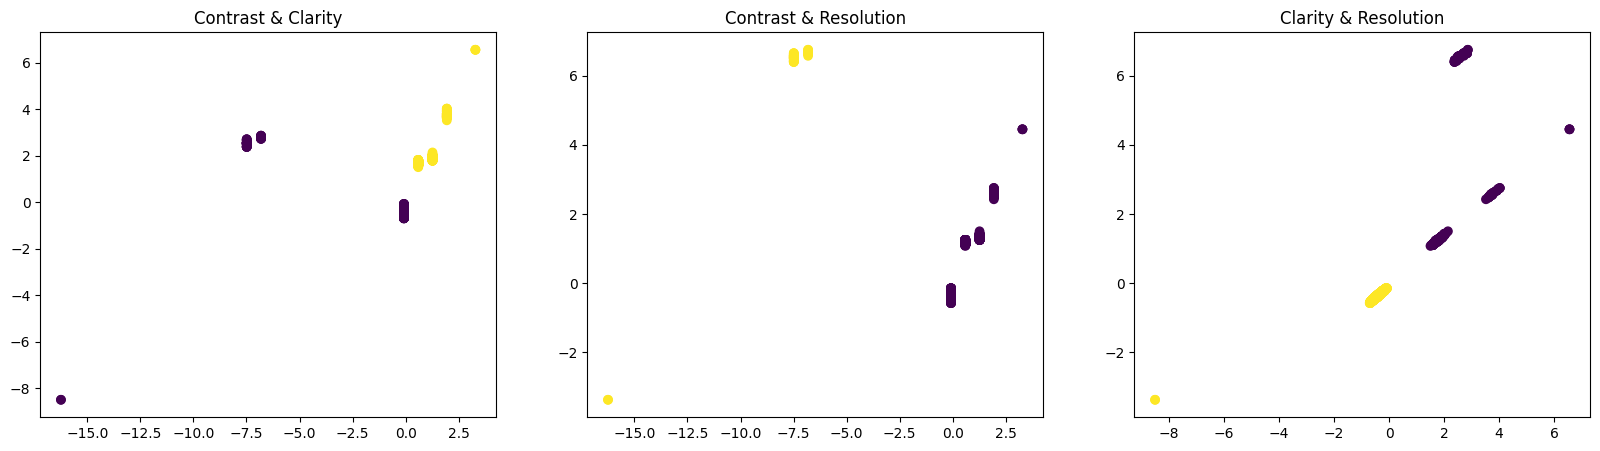

In [379]:
agg_graph(X_lib, labels_lib, graph_titles)